In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
# Loading the prediction files

arimax = pd.read_csv("../data/processed/arimax_predictions.csv")
prophet = pd.read_csv("../data/processed/prophet_predictions.csv")
lstm = pd.read_csv("../data/processed/lstm_predictions.csv")

print("ARIMAX:")
display(arimax.head())

print("\nProphet:")
display(prophet.head())

print("\nLSTM:")
display(lstm.head())

ARIMAX:


,Unnamed: 0,actual_food_inflation,predicted_food_inflation
0,144,8.30,9.272413
1,145,8.66,8.944435
2,146,8.52,8.870764
3,147,8.70,8.921603
4,148,8.69,8.985986



Prophet:


,ds,actual_food_inflation,predicted_food_inflation,lower_bound,upper_bound
0,2024-01-01,8.30,3.494633,-4.252491,10.806892
1,2024-02-01,8.66,3.064483,-4.147633,10.610422
2,2024-03-01,8.52,3.371879,-4.783906,11.144923
3,2024-04-01,8.70,3.606333,-3.861826,11.239079
4,2024-05-01,8.69,3.774561,-3.806463,10.954323



LSTM:


,date,actual_food_inflation,predicted_food_inflation
0,2024-01-01,8.30,10.134334
1,2024-02-01,8.66,10.661716
2,2024-03-01,8.52,11.091959
3,2024-04-01,8.70,11.420741
4,2024-05-01,8.69,11.638005


In [15]:
# Load the processed food inflation + ONI dataset

df = pd.read_csv("../data/processed/cpi_oni.csv")
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

display(df.head())
display(df.tail())

,date,food_inflation,oni,month
0,2012-01-01,-0.21,-0.72,1
1,2012-02-01,4.45,-0.57,2
2,2012-03-01,7.09,-0.46,3
3,2012-04-01,9.32,-0.36,4
4,2012-05-01,9.70,-0.17,5


,date,food_inflation,oni,month
163,2025-08-01,-0.64,-0.28,8
164,2025-09-01,-2.33,-0.40,9
165,2025-10-01,-5.02,-0.51,10
166,2025-11-01,-3.91,-0.55,11
167,2025-12-01,-2.71,-0.54,12


In [16]:
# Get the common 24-month test dates

TEST_SIZE = 24

test_dates = df.iloc[-TEST_SIZE:]["date"].reset_index(drop=True)

print("Test period:")
print(test_dates.min(), "to", test_dates.max())
print("Number of test months:", len(test_dates))

Test period:
2024-01-01 00:00:00 to 2025-12-01 00:00:00
Number of test months: 24


In [17]:
# Reconstruct ARIMAX dates

arimax["date"] = test_dates

arimax["date"] = pd.to_datetime(arimax["date"])

print("ARIMAX:")
display(arimax.head())
display(arimax.tail())

ARIMAX:


,date,actual,arimax
0,2024-01-01,8.30,9.272413
1,2024-02-01,8.66,8.944435
2,2024-03-01,8.52,8.870764
3,2024-04-01,8.70,8.921603
4,2024-05-01,8.69,8.985986


,date,actual,arimax
19,2025-08-01,-0.64,8.996930
20,2025-09-01,-2.33,9.010526
21,2025-10-01,-5.02,9.020736
22,2025-11-01,-3.91,9.029253
23,2025-12-01,-2.71,9.025919


In [18]:
print("ARIMAX:", arimax["date"].min(), "to", arimax["date"].max())
print("Prophet:", prophet["date"].min(), "to", prophet["date"].max())
print("LSTM:", lstm["date"].min(), "to", lstm["date"].max())

ARIMAX: 2024-01-01 00:00:00 to 2025-12-01 00:00:00
Prophet: 2024-01-01 00:00:00 to 2025-12-01 00:00:00
LSTM: 2024-01-01 00:00:00 to 2025-12-01 00:00:00


In [19]:
# Merge all model predictions on the common test dates

comparison = arimax.merge(
    prophet,
    on="date",
    how="inner"
)

comparison = comparison.merge(
    lstm,
    on="date",
    how="inner"
)

# Sort chronologically
comparison = comparison.sort_values("date").reset_index(drop=True)

display(comparison)

,date,actual,arimax,prophet,lstm_oni
0,2024-01-01,8.30,9.272413,3.494633,10.134334
1,2024-02-01,8.66,8.944435,3.064483,10.661716
2,2024-03-01,8.52,8.870764,3.371879,11.091959
3,2024-04-01,8.70,8.921603,3.606333,11.420741
4,2024-05-01,8.69,8.985986,3.774561,11.638005
5,2024-06-01,9.36,9.031746,4.063045,11.748594
6,2024-07-01,5.42,9.067350,4.647844,11.734598
7,2024-08-01,5.66,9.080946,4.603095,11.212293
8,2024-09-01,9.24,9.096234,4.381226,10.684888
9,2024-10-01,10.87,9.103058,4.433706,10.435041


In [20]:
print("Shape:", comparison.shape)
print("Date range:", comparison["date"].min(), "to", comparison["date"].max())
print("\nMissing values:")
print(comparison.isna().sum())

Shape: (24, 5)
Date range: 2024-01-01 00:00:00 to 2025-12-01 00:00:00

Missing values:
date        0
actual      0
arimax      0
prophet     0
lstm_oni    0
dtype: int64


In [22]:
#Creating Metric functions

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denominator == 0,0,np.abs(y_true - y_pred) / denominator)) * 100


def mase(y_true, y_pred, y_train):
    # Naive one-step forecast errors on training data
    naive_errors = np.abs(np.diff(y_train))

    scale = np.mean(naive_errors)

    if scale == 0:
        return np.nan

    return np.mean(np.abs(y_true - y_pred)) / scale

In [23]:
#Preparing actual and training values

y_true = comparison["actual"].values

# Training-period food inflation for MASE
y_train = df.iloc[:-TEST_SIZE]["food_inflation"].values


#Calculating metrics for each model

models = {
    "ARIMAX": comparison["arimax"].values,
    "Prophet": comparison["prophet"].values,
    "LSTM + ONI": comparison["lstm_oni"].values
}

results = []

for model_name, y_pred in models.items():

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    smape_value = smape(y_true, y_pred)

    mase_value = mase(
        y_true,
        y_pred,
        y_train
    )

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape_value,
        "MASE": mase_value
    })

metrics_df = pd.DataFrame(results)

display(metrics_df)

,Model,MAE,RMSE,sMAPE (%),MASE
0,ARIMAX,5.116283,6.968454,86.691679,3.802225
1,Prophet,4.524748,5.100074,103.685090,3.362619
2,LSTM + ONI,4.663408,5.349186,93.616087,3.465666


In [25]:
# Load LSTM baseline predictions

baseline = pd.read_csv(
    "../data/processed/lstm_baseline_predictions.csv"
)

display(baseline.head())
print("Baseline shape:", baseline.shape)

,date,actual_food_inflation,predicted_food_inflation
0,2024-01-01,8.30,9.557168
1,2024-02-01,8.66,8.105743
2,2024-03-01,8.52,8.814161
3,2024-04-01,8.70,8.572158
4,2024-05-01,8.69,8.701096


Baseline shape: (24, 3)


In [26]:
#Standardize baseline columns

baseline = baseline.rename(columns={
    "predicted_food_inflation": "lstm_baseline"
})

baseline["date"] = pd.to_datetime(baseline["date"])

baseline = baseline[["date", "lstm_baseline"]]

display(baseline.head())

,date,lstm_baseline
0,2024-01-01,9.557168
1,2024-02-01,8.105743
2,2024-03-01,8.814161
3,2024-04-01,8.572158
4,2024-05-01,8.701096


In [27]:
# Add LSTM baseline predictions

comparison = comparison.merge(
    baseline,
    on="date",
    how="inner"
)

comparison = comparison.sort_values("date").reset_index(drop=True)

display(comparison)

,date,actual,arimax,prophet,lstm_oni,lstm_baseline
0,2024-01-01,8.30,9.272413,3.494633,10.134334,9.557168
1,2024-02-01,8.66,8.944435,3.064483,10.661716,8.105743
2,2024-03-01,8.52,8.870764,3.371879,11.091959,8.814161
3,2024-04-01,8.70,8.921603,3.606333,11.420741,8.572158
4,2024-05-01,8.69,8.985986,3.774561,11.638005,8.701096
5,2024-06-01,9.36,9.031746,4.063045,11.748594,8.471540
6,2024-07-01,5.42,9.067350,4.647844,11.734598,9.053225
7,2024-08-01,5.66,9.080946,4.603095,11.212293,4.940202
8,2024-09-01,9.24,9.096234,4.381226,10.684888,6.066242
9,2024-10-01,10.87,9.103058,4.433706,10.435041,9.684754


In [28]:
print("Shape:", comparison.shape)
print("\nMissing values:")
print(comparison.isna().sum())

Shape: (24, 6)

Missing values:
date             0
actual           0
arimax           0
prophet          0
lstm_oni         0
lstm_baseline    0
dtype: int64


In [29]:
#Calculate metrics for LSTM baseline

y_true = comparison["actual"].values
y_pred_baseline = comparison["lstm_baseline"].values

baseline_mae = mean_absolute_error(
    y_true,
    y_pred_baseline
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred_baseline
    )
)

baseline_smape = smape(
    y_true,
    y_pred_baseline
)

baseline_mase = mase(
    y_true,
    y_pred_baseline,
    y_train
)

print("LSTM Baseline MAE:", baseline_mae)
print("LSTM Baseline RMSE:", baseline_rmse)
print("LSTM Baseline sMAPE:", baseline_smape)
print("LSTM Baseline MASE:", baseline_mase)

LSTM Baseline MAE: 1.31695564
LSTM Baseline RMSE: 1.658210644301315
LSTM Baseline sMAPE: 44.18516856184754
LSTM Baseline MASE: 0.978710813512663


In [30]:
# Add LSTM Baseline metrics to the results table

metrics_df.loc[len(metrics_df)] = {
    "Model": "LSTM Baseline",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "sMAPE (%)": baseline_smape,
    "MASE": baseline_mase
}

display(metrics_df)

,Model,MAE,RMSE,sMAPE (%),MASE
0,ARIMAX,5.116283,6.968454,86.691679,3.802225
1,Prophet,4.524748,5.100074,103.685090,3.362619
2,LSTM + ONI,4.663408,5.349186,93.616087,3.465666
3,LSTM Baseline,1.316956,1.658211,44.185169,0.978711


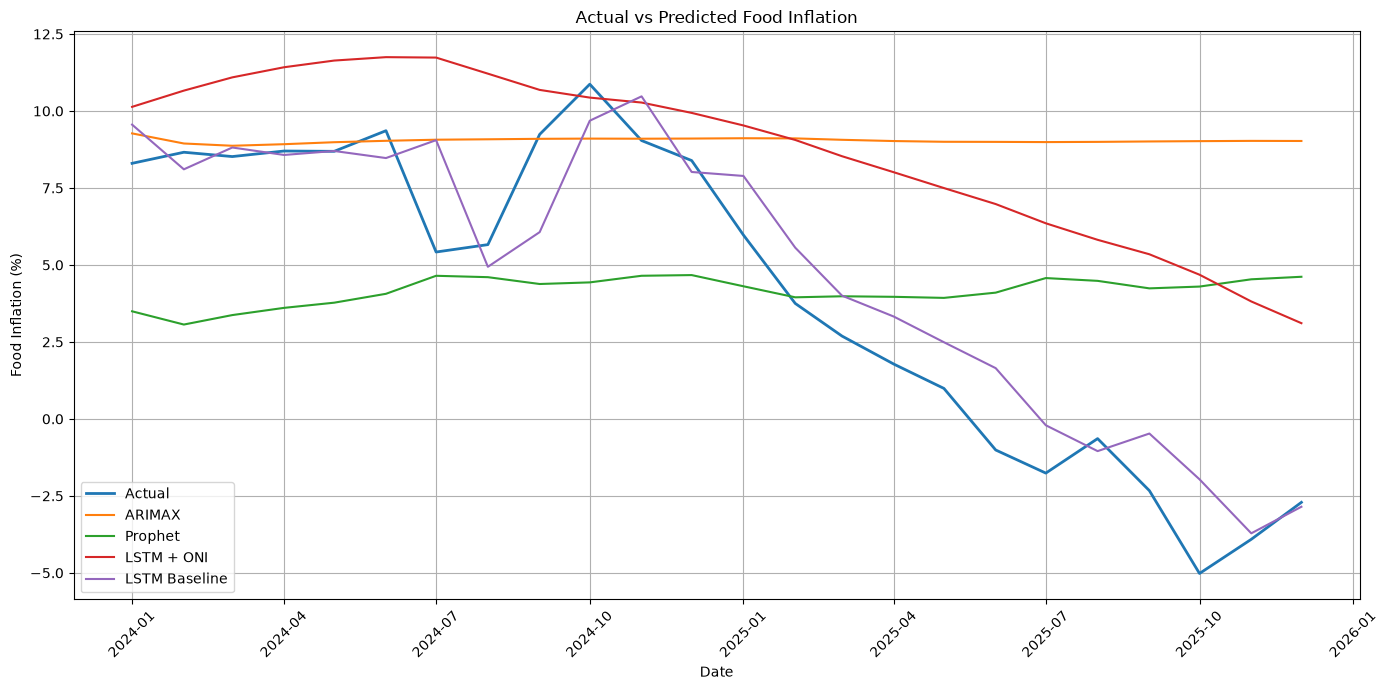

In [31]:
#Actual vs predicted food inflation

plt.figure(figsize=(14, 7))

plt.plot(
    comparison["date"],
    comparison["actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    comparison["date"],
    comparison["arimax"],
    label="ARIMAX"
)

plt.plot(
    comparison["date"],
    comparison["prophet"],
    label="Prophet"
)

plt.plot(
    comparison["date"],
    comparison["lstm_oni"],
    label="LSTM + ONI"
)

plt.plot(
    comparison["date"],
    comparison["lstm_baseline"],
    label="LSTM Baseline"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("Actual vs Predicted Food Inflation")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

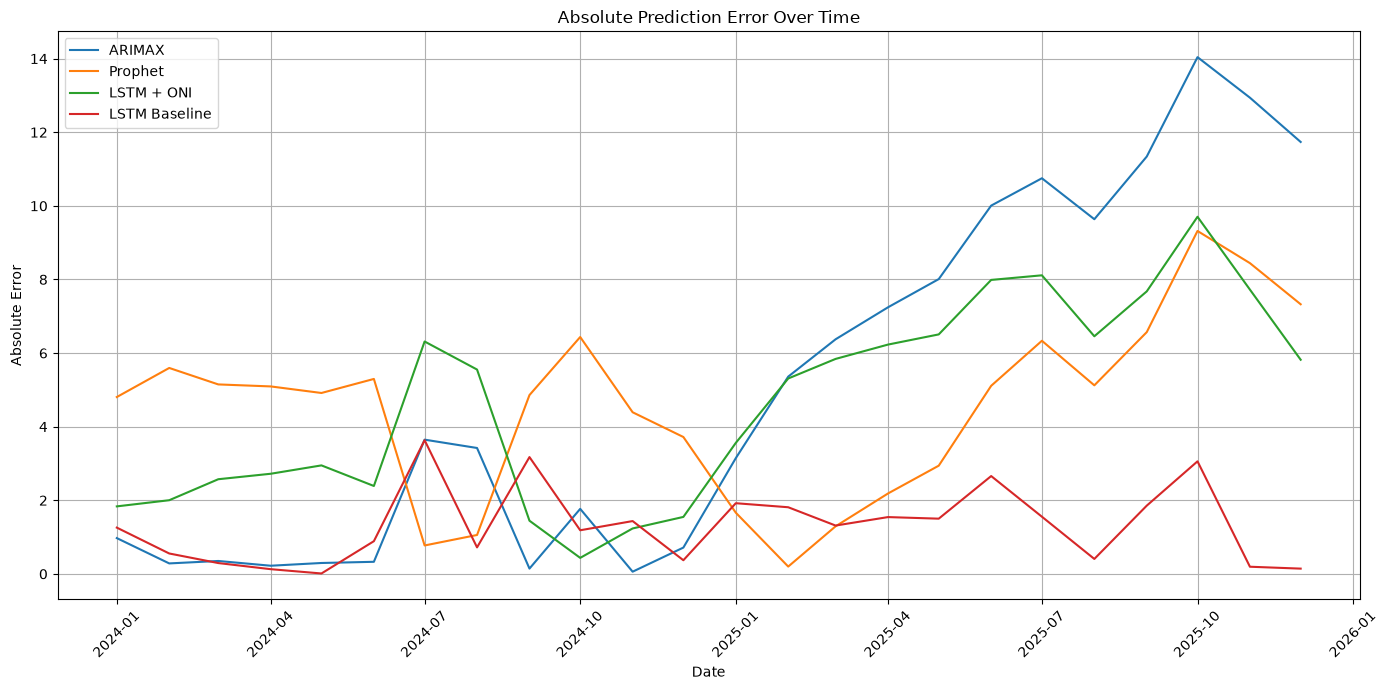

In [32]:
# Calculate absolute errors

comparison["ARIMAX_error"] = np.abs(
    comparison["actual"] - comparison["arimax"]
)

comparison["Prophet_error"] = np.abs(
    comparison["actual"] - comparison["prophet"]
)

comparison["LSTM_ONI_error"] = np.abs(
    comparison["actual"] - comparison["lstm_oni"]
)

comparison["LSTM_baseline_error"] = np.abs(
    comparison["actual"] - comparison["lstm_baseline"]
)
plt.figure(figsize=(14, 7))

plt.plot(
    comparison["date"],
    comparison["ARIMAX_error"],
    label="ARIMAX"
)

plt.plot(
    comparison["date"],
    comparison["Prophet_error"],
    label="Prophet"
)

plt.plot(
    comparison["date"],
    comparison["LSTM_ONI_error"],
    label="LSTM + ONI"
)

plt.plot(
    comparison["date"],
    comparison["LSTM_baseline_error"],
    label="LSTM Baseline"
)

plt.xlabel("Date")
plt.ylabel("Absolute Error")
plt.title("Absolute Prediction Error Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

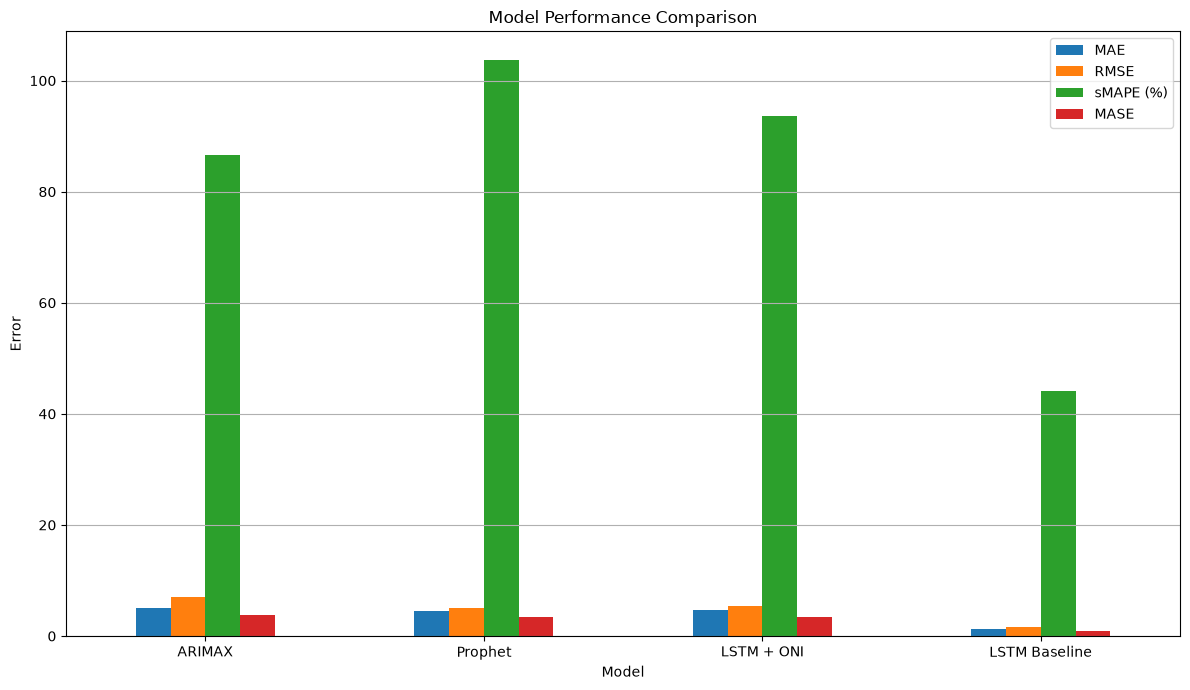

In [33]:
#Metric comparison

metrics_plot = metrics_df.set_index("Model")

metrics_plot[["MAE", "RMSE", "sMAPE (%)", "MASE"]].plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [34]:
#Rank models for each evaluation metric
#Lower error = better model

ranking = metrics_df.copy()

for metric in ["MAE", "RMSE", "sMAPE (%)", "MASE"]:
    ranking[f"{metric} Rank"] = ranking[metric].rank(
        ascending=True,
        method="min"
    ).astype(int)

display(ranking)

,Model,MAE,RMSE,sMAPE (%),MASE,MAE Rank,RMSE Rank,sMAPE (%) Rank,MASE Rank
0,ARIMAX,5.116283,6.968454,86.691679,3.802225,4,4,2,4
1,Prophet,4.524748,5.100074,103.685090,3.362619,2,2,4,2
2,LSTM + ONI,4.663408,5.349186,93.616087,3.465666,3,3,3,3
3,LSTM Baseline,1.316956,1.658211,44.185169,0.978711,1,1,1,1


In [35]:
#Calculate average rank across all metrics

ranking["Average Rank"] = ranking[
    ["MAE Rank", "RMSE Rank", "sMAPE (%) Rank", "MASE Rank"]
].mean(axis=1)

ranking = ranking.sort_values("Average Rank")

display(ranking)

,Model,MAE,RMSE,sMAPE (%),MASE,MAE Rank,RMSE Rank,sMAPE (%) Rank,MASE Rank,Average Rank
3,LSTM Baseline,1.316956,1.658211,44.185169,0.978711,1,1,1,1,1.0
1,Prophet,4.524748,5.100074,103.685090,3.362619,2,2,4,2,2.5
2,LSTM + ONI,4.663408,5.349186,93.616087,3.465666,3,3,3,3,3.0
0,ARIMAX,5.116283,6.968454,86.691679,3.802225,4,4,2,4,3.5


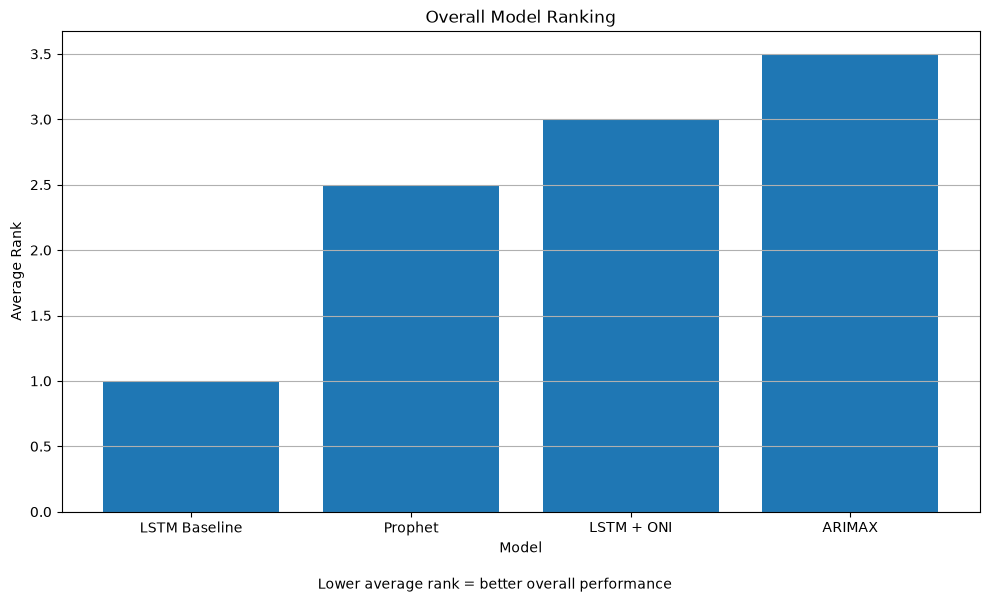

In [37]:
#Pictorial representation for ranking
#Overall model ranking based on average metric rank

plt.figure(figsize=(10, 6))

plt.bar(
    ranking["Model"],
    ranking["Average Rank"]
)

plt.xlabel("Model")
plt.ylabel("Average Rank")
plt.title("Overall Model Ranking")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.figtext(
    0.5, 0.01,
    "Lower average rank = better overall performance",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [38]:
#Final model comparison conclusion

best_model = ranking.iloc[0]["Model"]

print("FINAL MODEL COMPARISON")
print("=" * 40)

print(f"Best overall model: {best_model}")

print("\nPerformance summary:")
print(ranking[
    ["Model", "MAE", "RMSE", "sMAPE (%)", "MASE", "Average Rank"]
].to_string(index=False))

print("\nConclusion:")
print(
    f"{best_model} achieved the best overall performance "
    f"based on the lowest average rank across MAE, RMSE, sMAPE, and MASE."
)

FINAL MODEL COMPARISON
Best overall model: LSTM Baseline

Performance summary:
        Model      MAE     RMSE  sMAPE (%)     MASE  Average Rank
LSTM Baseline 1.316956 1.658211  44.185169 0.978711           1.0
      Prophet 4.524748 5.100074 103.685090 3.362619           2.5
   LSTM + ONI 4.663408 5.349186  93.616087 3.465666           3.0
       ARIMAX 5.116283 6.968454  86.691679 3.802225           3.5

Conclusion:
LSTM Baseline achieved the best overall performance based on the lowest average rank across MAE, RMSE, sMAPE, and MASE.
